# Exploratory Data Analysis (EDA) — Branch, Merchant, Complaint & Loan Analysis

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the cleaned **branch**, **merchant**, **complaint**, and **loan** datasets from the banking analytics project.

The objective is to analyze branch performance, merchant transaction patterns, customer complaint trends, and loan portfolios to understand operational efficiency, customer service performance, and lending behavior across the bank.

The cleaned datasets prepared during the Data Cleaning phase are used throughout this notebook.

> **Note:** Customer, Account, Transaction, and Card analysis are covered in separate notebooks.

---

## Business Questions Covered in This Notebook

### Branch Analysis

* Which branches process the highest number of transactions?
* How are branches distributed across different cities and regions?

### Merchant Analysis

* Which merchant categories generate the highest transaction volume?
* Which merchant categories contribute the highest transaction value?

### Complaint Analysis

* Which complaint types are reported most frequently?
* What is the distribution of complaint statuses?
* Which complaint channels are used most often?
* How long does it typically take to resolve customer complaints?

### Loan Analysis

* Which loan types are issued most frequently?
* What is the average loan amount by loan type?
* How are customers distributed across different loan risk categories?
* How does loan default rate vary across risk categories?
* What is the relationship between loan amount, EMI, monthly income, and credit score?
* How are interest rates distributed across different loan types?

---

## Expected Outcome

By the end of this notebook, meaningful insights will be obtained into branch operations, merchant activity, complaint management, and loan performance. These findings help evaluate operational efficiency, customer service quality, lending patterns, and portfolio risk, while also supporting the development of interactive Tableau dashboards in the final phase of the project.


## Import Libraries

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')



## Loading the Cleaned Datasets

In [2]:
branches = pd.read_csv("data/Cleaned/dim_branches.csv")
merchants = pd.read_csv("data/Cleaned/dim_merchants.csv")
customers = pd.read_csv("data/Cleaned/dim_customers.csv")
accounts = pd.read_csv("data/Cleaned/dim_accounts.csv")
transactions = pd.read_csv("data/Cleaned/fact_transactions.csv")
complaints = pd.read_csv("data/Cleaned/fact_complaints.csv")
loans = pd.read_csv("data/Cleaned/fact_loans.csv")


In [3]:
# Merge transactions with branch_id (so we know which branch each transaction belongs to)
txn_branch = transactions.merge(accounts[['account_id', 'branch_id']], on='account_id', how='left')

# Merge transactions with merchant details (so we know the merchant category for each transaction)
txn_merchant = transactions.merge(merchants, on='merchant_id', how='left')

# Merge complaints with customer segment (so we know which segment filed each complaint)
comp_customer = complaints.merge(customers[['customer_id', 'customer_segment']], on='customer_id', how='left')

# Merge loan data with customer details (one row per loan)
loan_data = loans.merge(customers, on='customer_id', how='left')


## Question 1: How many branches does the bank have in each city?

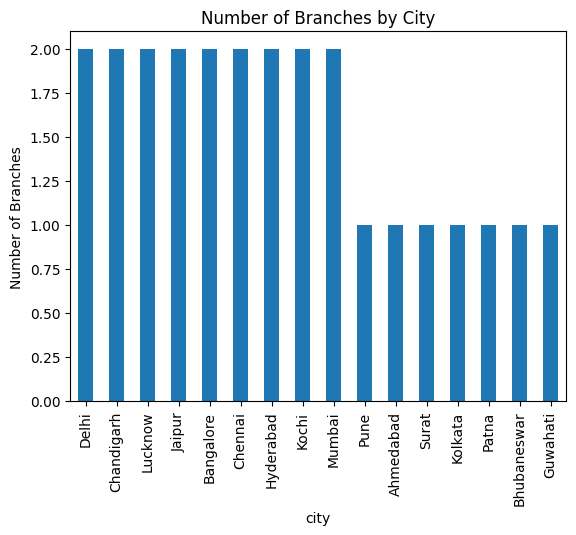

In [4]:
branches['city'].value_counts().plot(kind='bar')
plt.title('Number of Branches by City')
plt.ylabel('Number of Branches')
plt.show()

### Observation

Most major cities (Delhi, Mumbai, Bangalore, Chennai, Hyderabad, Kochi, Jaipur, Chandigarh, Lucknow) have **2 branches each**, while smaller cities like Pune, Ahmedabad, Surat, Kolkata, Patna, Bhubaneswar and Guwahati have only **1 branch**. This shows the bank has spread branches fairly evenly across many cities instead of concentrating them in just a few locations.

## Question 2: Which branches have the most employees?

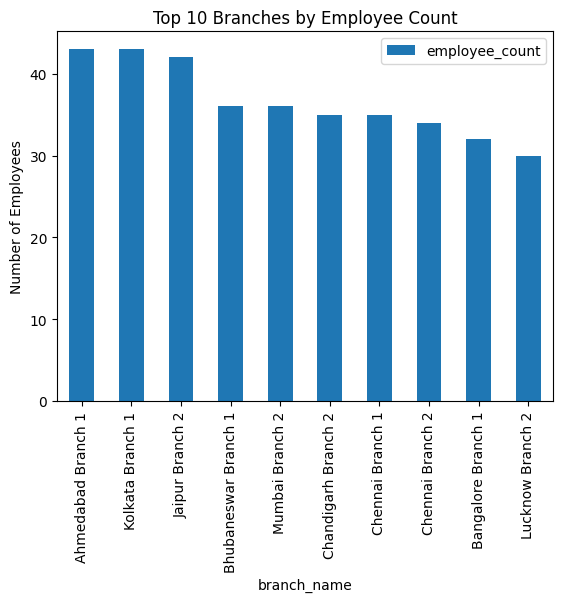

In [5]:
branches.sort_values('employee_count', ascending=False).head(10).plot(x='branch_name', y='employee_count', kind='bar')
plt.title('Top 10 Branches by Employee Count')
plt.ylabel('Number of Employees')
plt.show()

### Observation

The top branches (Ahmedabad Branch 1 and Kolkata Branch 1) have around **43 employees**, only slightly higher than the rest of the top 10, which are mostly in the **30-36 employee** range. There isn't one branch that stands out dramatically - staffing levels look fairly consistent across the bank's larger branches.

## Question 3: Which branches handle the most transactions?

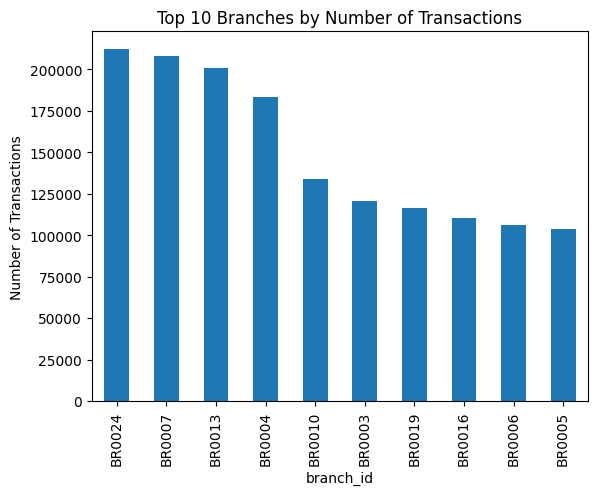

In [6]:
txn_branch['branch_id'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Branches by Number of Transactions')
plt.ylabel('Number of Transactions')
plt.show()

### Observation

Branch BR0024 has the highest number of transactions (a little over 200,000), followed closely by BR0007 and BR0013. There is a noticeable drop after the top 4 branches, with the remaining branches in the top 10 handling **roughly half as many transactions** (around 100,000-135,000). This shows transaction volume is concentrated in a few high-traffic branches.

## Question 4. Which merchant categories handle the highest total transaction amount?

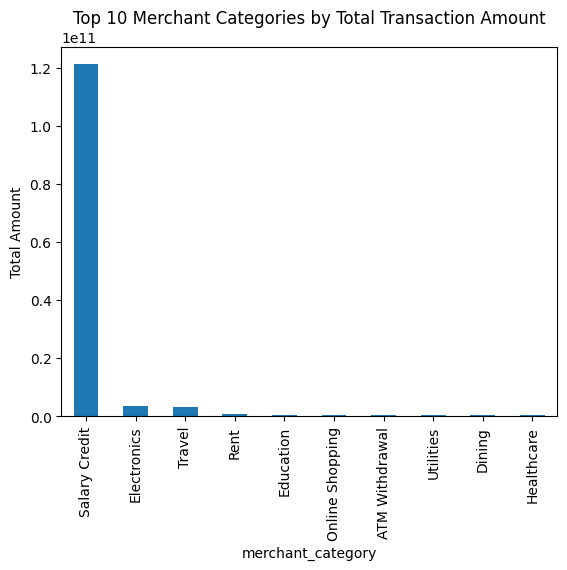

In [7]:
txn_merchant.groupby('merchant_category')['amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Merchant Categories by Total Transaction Amount')
plt.ylabel('Total Amount')
plt.show()

### Observation

**Salary Credit** completely dominates this chart, with a total transaction amount far higher than every other category combined - so much higher that the other bars (Electronics, Travel, Rent, etc.) barely show up next to it. This makes sense since salary payments are usually large, regular transactions. This also means that even though Salary Credit had the *fewest* merchants in Question 6, it carries by far the most transaction value, so merchant count and transaction value don't move together.

## Question 5. What is the average transaction amount in each merchant category?

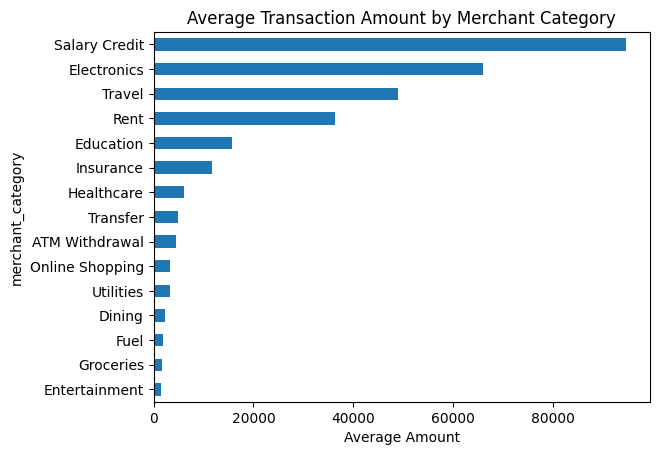

In [8]:
txn_merchant.groupby('merchant_category')['amount'].mean().sort_values().plot(kind='barh')
plt.title('Average Transaction Amount by Merchant Category')
plt.xlabel('Average Amount')
plt.show()

### Observation

Salary Credit also has by far the highest **average** transaction amount, followed by Electronics and Travel. Everyday spending categories like Groceries, Fuel, Dining, and Entertainment have much smaller average amounts, which lines up with how people normally use these categories in real life (small frequent purchases vs. large one-off payments).

## Question 6. Which merchant categories have the highest fraud rate?

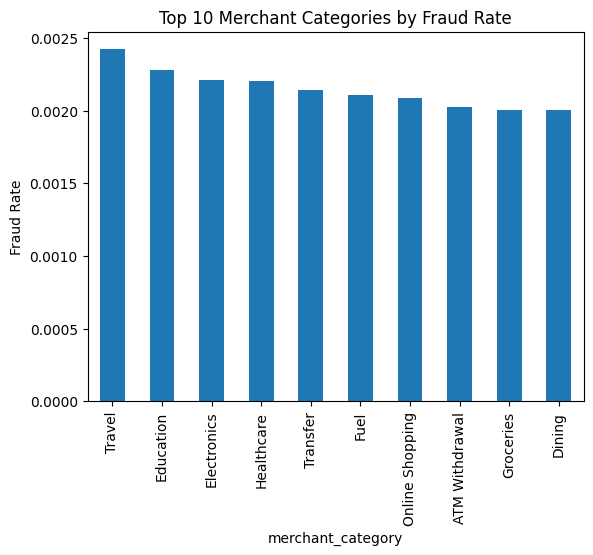

In [9]:
# Using the mean of is_fraud (a 0/1 column) gives the FRAUD RATE, not just the raw count.
# This is more useful for comparing categories fairly, since some categories have many more transactions than others.
txn_merchant.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Merchant Categories by Fraud Rate')
plt.ylabel('Fraud Rate')
plt.show()

### Observation

Looking at the fraud **rate** (fraud cases divided by total transactions) instead of just the raw fraud count gives a fairer picture, since high-volume categories like Groceries would otherwise look riskier just because they have more transactions overall. This chart shows which categories have the highest *proportion* of fraudulent transactions, which is more useful for the fraud team than raw counts alone.

## Question 7. What types of complaints do customers file the most?

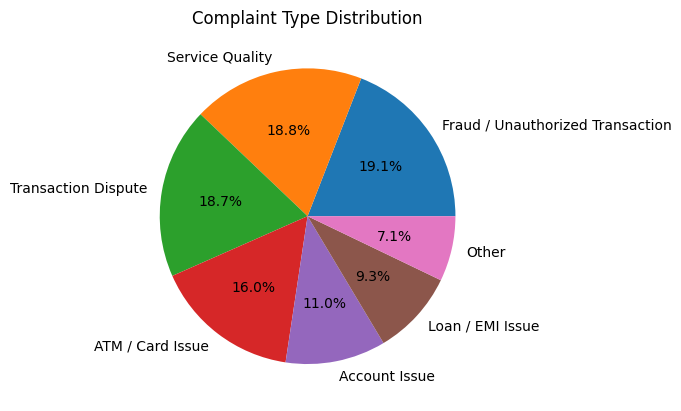

In [10]:
complaints['complaint_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Complaint Type Distribution')
plt.ylabel('')
plt.show()

### Observation

**Fraud/Unauthorized Transaction (19.1%)**, **Service Quality (18.8%)**, and **Transaction Dispute (18.7%)** are the three most common complaint types, and they are very close to each other. **ATM/Card Issue** is also significant at 16.0%. Together, these four types make up the large majority of all complaints, while Loan/EMI Issue and "Other" are less common.

## Question 8. What is the current status of complaints?

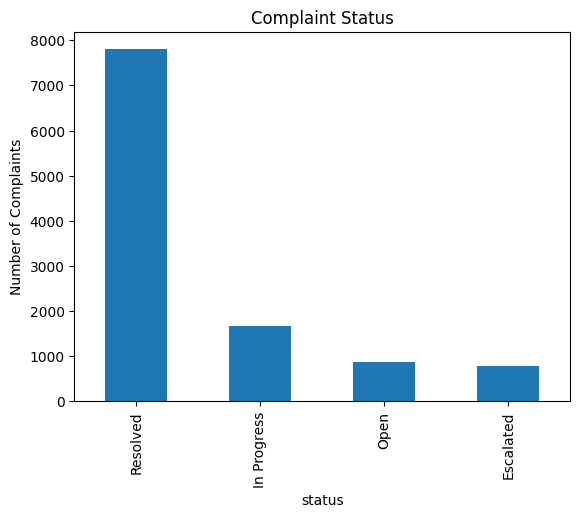

In [11]:
complaints['status'].value_counts().plot(kind='bar')
plt.title('Complaint Status')
plt.ylabel('Number of Complaints')
plt.show()

### Observation

Most complaints (around 7,800) are marked **Resolved**, which is a good sign. A much smaller number are **In Progress** (around 1,650), and even fewer are **Open** or **Escalated** (under 900 each). This means the bank resolves the large majority of complaints, with only a small portion still pending or escalated.

## Question 9. How are complaints distributed by priority level?

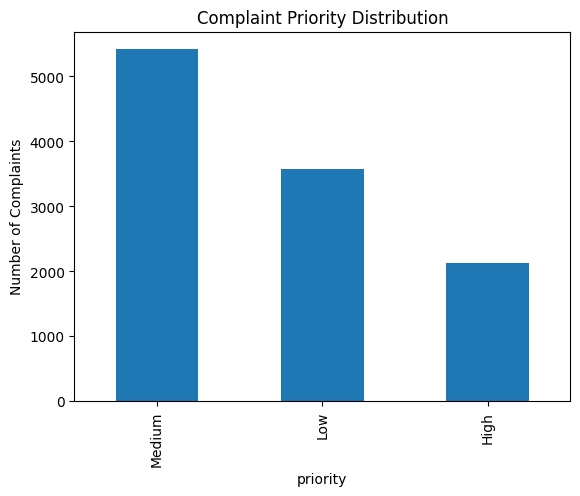

In [12]:
complaints['priority'].value_counts().plot(kind='bar')
plt.title('Complaint Priority Distribution')
plt.ylabel('Number of Complaints')
plt.show()

### Observation

Most complaints are marked **Medium** priority (around 5,400), followed by **Low** priority (around 3,550). **High** priority complaints are the smallest group (around 2,100). This suggests most issues reported by customers are not extremely urgent, though it's worth checking in Question 15 whether "High" priority complaints are actually resolved faster.

## Question 10. Which channel do customers use most to file complaints?

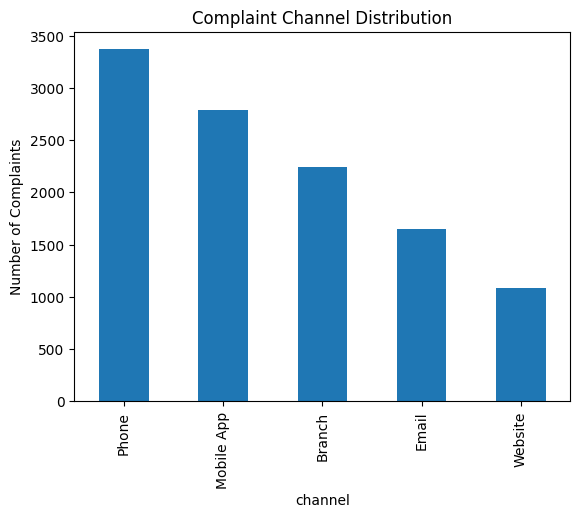

In [13]:
complaints['channel'].value_counts().plot(kind='bar')
plt.title('Complaint Channel Distribution')
plt.ylabel('Number of Complaints')
plt.show()

### Observation

**Phone** is the most common channel customers use to file complaints (around 3,375), followed by **Mobile App** (around 2,800) and **Branch** (around 2,250). **Email** and **Website** are used the least. This shows that customers still prefer speaking to someone directly (Phone) or using the app, over slower channels like email.

## Question 11. How long does it typically take to resolve a complaint?

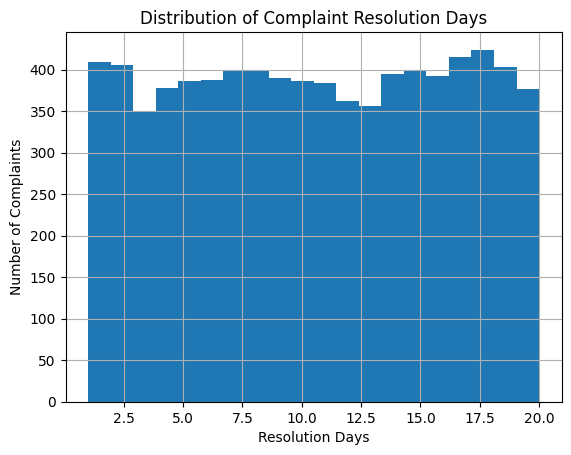

In [14]:
complaints['resolution_days'].hist(bins=20)
plt.title('Distribution of Complaint Resolution Days')
plt.xlabel('Resolution Days')
plt.ylabel('Number of Complaints')
plt.show()

### Observation

Resolution time is spread quite evenly across **1 to 20 days**, with no single resolution time standing out as far more common than others. This roughly even spread suggests resolution time may depend on case-by-case factors rather than following a typical pattern (for example, most complaints clustering around a few days).

#  Loan Analysis

**Project:** Banking Data Analyst Capstone Project
**Notebook purpose:** Explore the cleaned loan dataset to answer exploratory analysis questions about loan status, loan types, pricing (interest rate/EMI), risk, and default behaviour, using simple pandas and matplotlib charts.

##  View Sample Records

In [15]:
loan_data.head()

,loan_id,customer_id,loan_type,loan_amount,interest_rate,tenure_months,emi,disbursement_date,outstanding_balance,loan_status,...,kyc_status,signup_date,city,state,home_branch_id,is_digital_banking_user,is_upi_user,is_mobile_app_user,sms_alerts_enabled,is_insurance_holder
0,LOAN000001,CUST144098,Personal Loan,88751.70,13.57,57,2120.90,2024-02-02,71624.18,Active,...,Verified,2023-12-31,Jaipur,Rajasthan,BR0004,False,False,False,True,False
1,LOAN000002,CUST108716,Home Loan,2365927.69,8.78,359,18674.16,2023-08-11,2260482.44,Active,...,Verified,2023-01-03,Kolkata,West Bengal,BR0013,True,True,False,False,False
2,LOAN000003,CUST104955,Home Loan,2276145.49,9.04,189,22623.88,2024-09-20,2240016.20,Active,...,Verified,2023-08-08,Kochi,Kerala,BR0008,False,True,True,False,True
3,LOAN000004,CUST040396,Education Loan,1745930.01,10.28,172,19438.86,2024-07-14,1695176.23,Active,...,Verified,2023-01-09,Hyderabad,Telangana,BR0007,False,True,False,True,True
4,LOAN000005,CUST098349,Education Loan,1873734.07,10.32,176,20700.13,2024-09-14,1841795.42,Active,...,Verified,2023-08-04,Jaipur,Rajasthan,BR0004,True,False,True,True,True


## Question 1: Loan Status Distribution

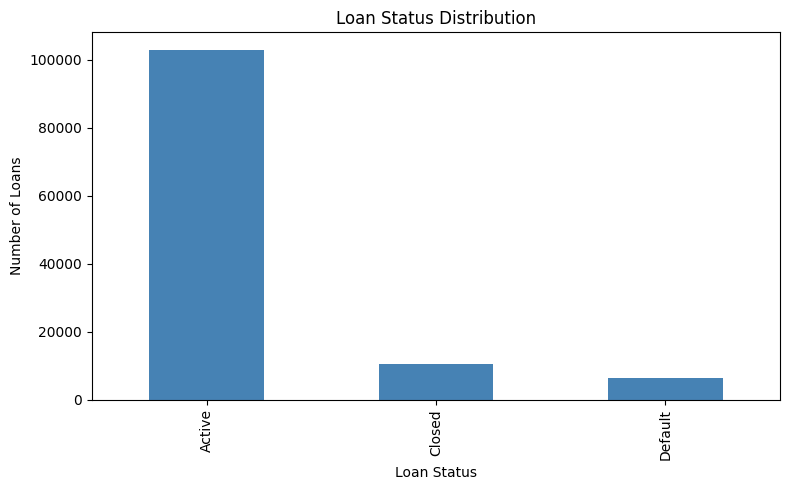

In [16]:
plt.figure(figsize=(8,5))
loan_data['loan_status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.tight_layout()
plt.show()

### Observation

Active loans make up the large majority of the portfolio, with Closed and Default loans each making up a much smaller share, and Default being the smallest of the three.


## Question 2: Loan Type Distribution

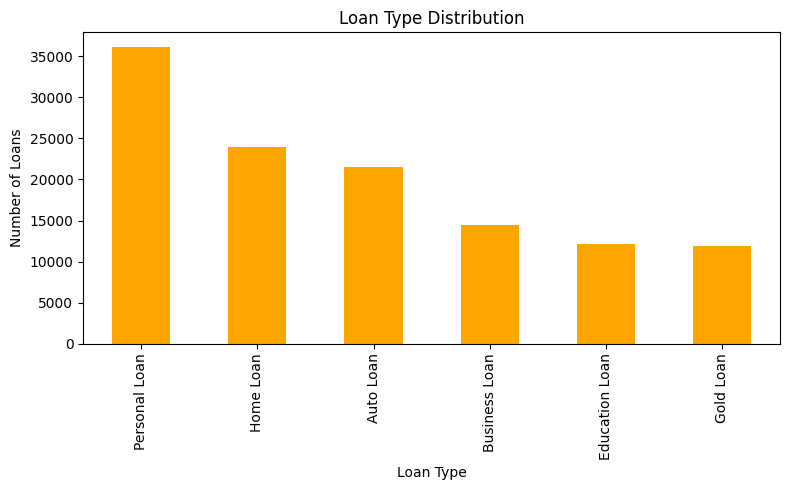

In [17]:
plt.figure(figsize=(8,5))
loan_data['loan_type'].value_counts().plot(kind='bar', color='orange')
plt.title('Loan Type Distribution')
plt.xlabel('Loan Type')
plt.ylabel('Number of Loans')
plt.tight_layout()
plt.show()

### Observation

Personal Loan is the most common loan type by a clear margin, followed by Home Loan and Auto Loan. Business, Education, and Gold Loans are issued far less often and are roughly similar in volume to each other.


## Question 3: Average Loan Amount by Loan Type

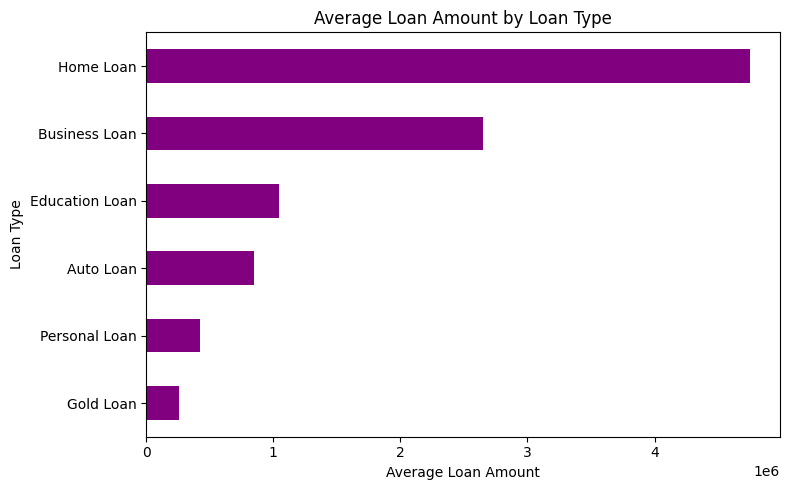

In [18]:
plt.figure(figsize=(8,5))
loan_data.groupby('loan_type')['loan_amount'].mean().sort_values().plot(kind='barh', color='purple')
plt.title('Average Loan Amount by Loan Type')
plt.xlabel('Average Loan Amount')
plt.ylabel('Loan Type')
plt.tight_layout()
plt.show()

### Observation

Home Loan has by far the highest average loan amount, followed by Business Loan. Education, Auto, and Personal Loans are much smaller on average, with Gold Loan being the smallest.


## Question 4: Default Rate by Risk Category

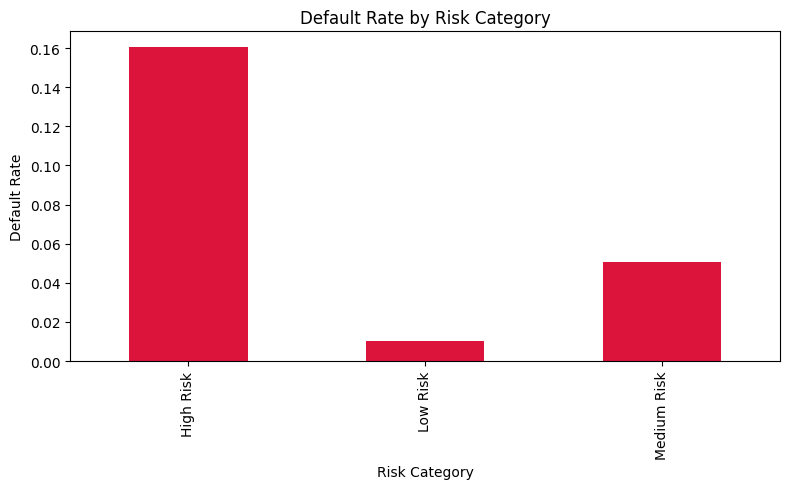

In [19]:
plt.figure(figsize=(8,5))
loan_data.groupby('risk_category')['default_flag'].mean().plot(kind='bar', color='crimson')
plt.title('Default Rate by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

### Observation

There is a strong, clear pattern: High Risk loans default far more often than Medium Risk loans, which in turn default more often than Low Risk loans.


## Question 5: Credit Score vs Loan Amount

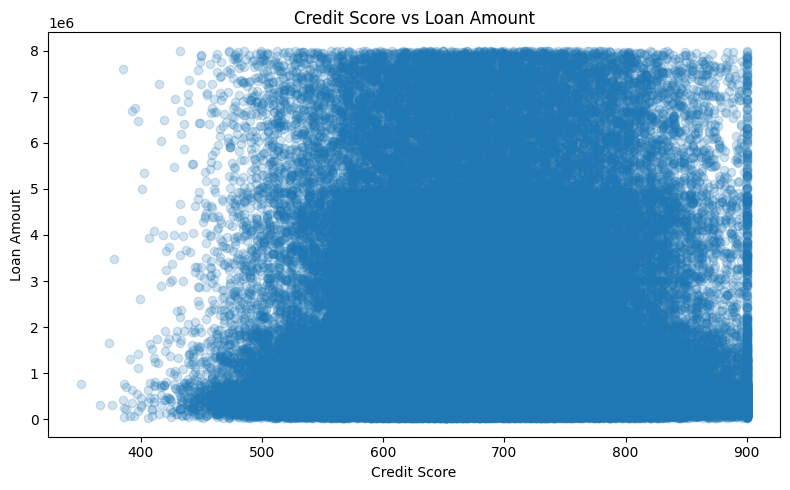

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(loan_data['credit_score'], loan_data['loan_amount'], alpha=0.2)
plt.xlabel('Credit Score')
plt.ylabel('Loan Amount')
plt.title('Credit Score vs Loan Amount')
plt.tight_layout()
plt.show()

### Observation

There's no visible relationship between credit score and loan amount — loans of every size appear across the full credit score range.


## Question 6: Loan Trend Over Time

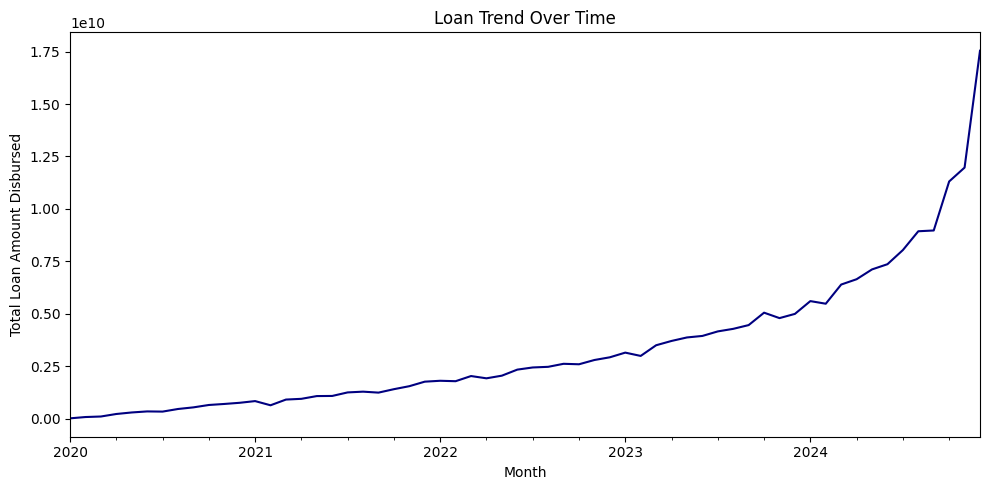

In [21]:
plt.figure(figsize=(10,5))
loan_data['disbursement_date'] = pd.to_datetime(loan_data['disbursement_date'])
loan_data.groupby(loan_data['disbursement_date'].dt.to_period('M'))['loan_amount'].sum().plot(color='navy')
plt.title('Loan Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Loan Amount Disbursed')
plt.tight_layout()
plt.show()

### Observation

The monthly disbursed loan trend can be interpreted after running the visualization. Describe whether the trend is increasing, decreasing, stable, or seasonal based on the chart output.

## Question 7: Correlation Heatmap

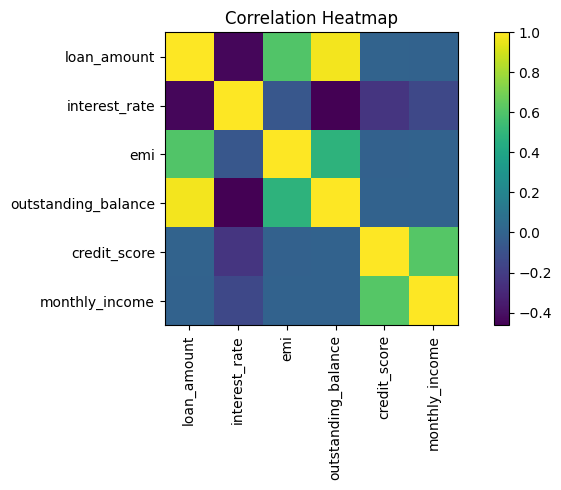

In [22]:
plt.figure(figsize=(8,5))
corr = loan_data[['loan_amount','interest_rate','emi','outstanding_balance','credit_score','monthly_income']].corr()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows a strong positive relationship between EMI and loan amount, while credit score and monthly income have weak correlations with loan amount. Most other variables exhibit low correlation, indicating limited linear relationships.

## Key Takeaways

### Branch, Merchant & Complaint Analysis

* Branches are distributed fairly evenly across major cities (typically two branches per large city and one in smaller cities), but transaction activity is concentrated. **Branch BR0024** processes over **200,000 transactions**, making it the highest-performing branch.
* **Salary Credit** accounts for the highest transaction value despite having the fewest merchants, indicating that transaction volume and transaction value do not necessarily correlate.
* **Fraud/Unauthorized Transactions (19.1%)**, **Service Quality (18.8%)**, and **Transaction Disputes (18.7%)** are the most common complaint categories, followed closely by **ATM/Card Issues (16.0%)**.
* Most customer complaints are successfully **resolved**, and the **Phone** channel is the preferred medium for complaint registration, followed by the **Mobile App** and **Branch** channels.
* Complaint resolution times are fairly evenly distributed between **1 and 20 days**, suggesting that turnaround time is influenced more by case complexity than by a fixed service timeline.

### Loan Analysis

* **Personal Loans** are the most frequently issued loan product, whereas **Home Loans** have the highest average loan amount.
* Loan default rates increase consistently from **Low Risk** to **Medium Risk** and **High Risk**, indicating that the bank's risk classification effectively identifies higher-risk borrowers.
* **EMI** shows a strong positive relationship with loan amount, while **credit score** and **monthly income** exhibit only a weak correlation with loan size.
* Interest rates are grouped into two distinct pricing clusters, and **loan type alone is not a strong predictor of default** once customer risk category is considered.
